In [1]:
import numpy as np
import pandas as pd

Loading each country data and concatenating

In [2]:
df1=pd.read_csv("Data/ethiopia_clean.csv")
df2=pd.read_csv("Data/kenya_clean.csv")
df3=pd.read_csv("Data/sudan_clean.csv")
df4=pd.read_csv("Data/tanzania_clean.csv")
df5=pd.read_csv("Data/nigeria_clean.csv")

combined_df = pd.concat([df1, df2,df3,df4,df5], ignore_index=True)

In [3]:
#checking the concatenated version
display(combined_df.head(3)) # in here country expected is Ethiopia since it on the top of the concatination
display(combined_df.tail(3)) # in here Nigeria is expected since it is concatenated last

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,month
20537,2026,88,27.72,29.53,26.21,3.32,1.43,82.83,1.10,1.78,100.61,19.22,nigeria,2026-03-29,3
20538,2026,89,28.42,31.17,26.36,4.81,0.85,77.73,2.30,3.40,100.53,18.73,nigeria,2026-03-30,3
20539,2026,90,28.40,31.73,26.32,5.41,5.33,78.79,1.76,2.80,100.59,18.94,nigeria,2026-03-31,3


Temperature Trend Comparison

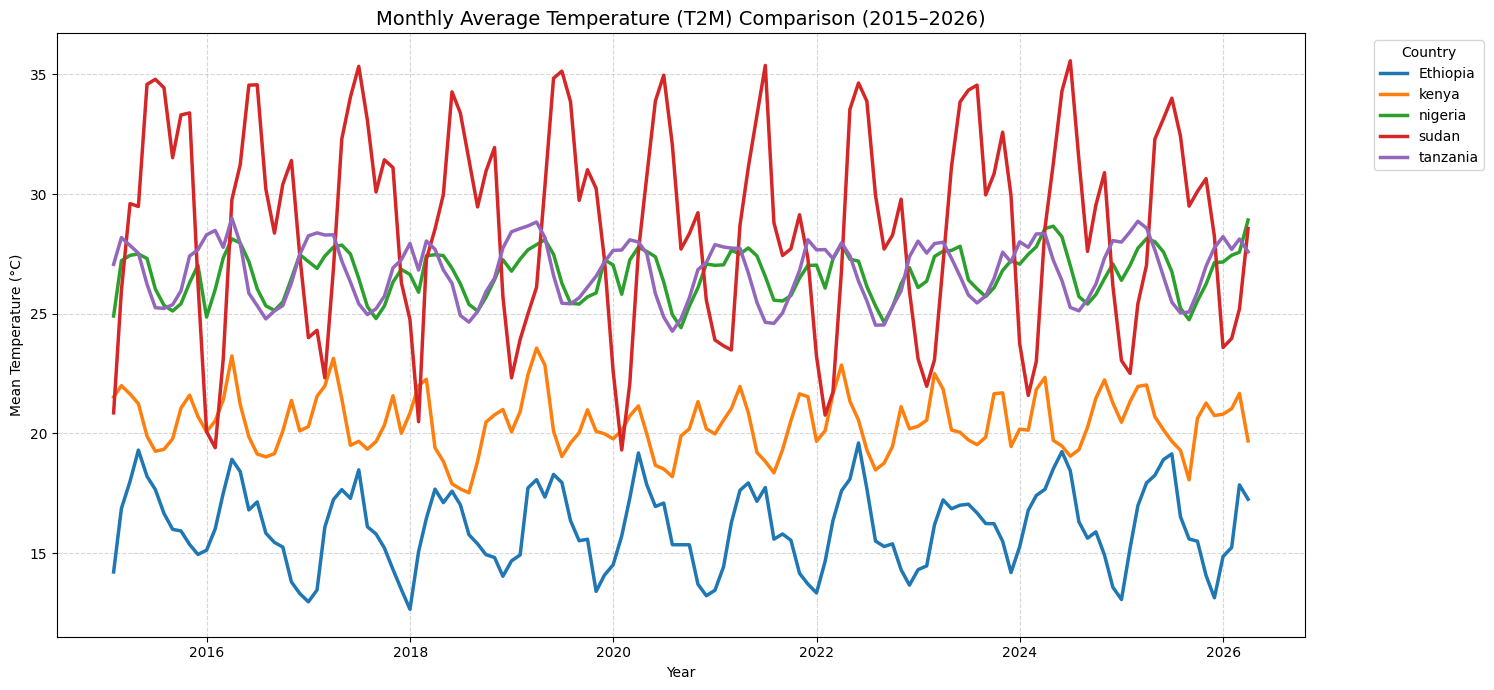

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ensure 'date' is datetime (Crucial for pd.Grouper)
combined_df['date'] = pd.to_datetime(combined_df['date'])

monthly_df = combined_df.groupby(['Country', pd.Grouper(key='date', freq='ME')])['T2M'].mean().reset_index()

# 2. Plotting  
plt.figure(figsize=(15, 7))
sns.lineplot(data=monthly_df, x='date', y='T2M', hue='Country', linewidth=2.5)

plt.title("Monthly Average Temperature (T2M) Comparison (2015–2026)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Mean Temperature (°C)")
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [5]:
# Create the summary table
summary_table = combined_df.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).reset_index()

# Rename the columns for a professional look
summary_table.columns = ['Country', 'Mean Temp (°C)', 'Median Temp (°C)', 'Std Deviation']

# Display the table rounded to 2 decimal places
print("Comparison of Temperature (T2M) Statistics (2015-2026):")
display(summary_table.round(2))

Comparison of Temperature (T2M) Statistics (2015-2026):


,Country,Mean Temp (°C),Median Temp (°C),Std Deviation
0,Ethiopia,16.07,16.04,1.90
1,kenya,20.43,20.36,1.44
2,nigeria,26.66,26.82,1.12
3,sudan,28.76,29.16,4.68
4,tanzania,26.80,26.99,1.33


Precipitation Variability Comparison

/var/folders/d9/fl1vk6zx3p950w23l303nhy40000gn/T/ipykernel_879/2352040114.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_df, x='Country', y='PRECTOTCORR', palette='Blues')


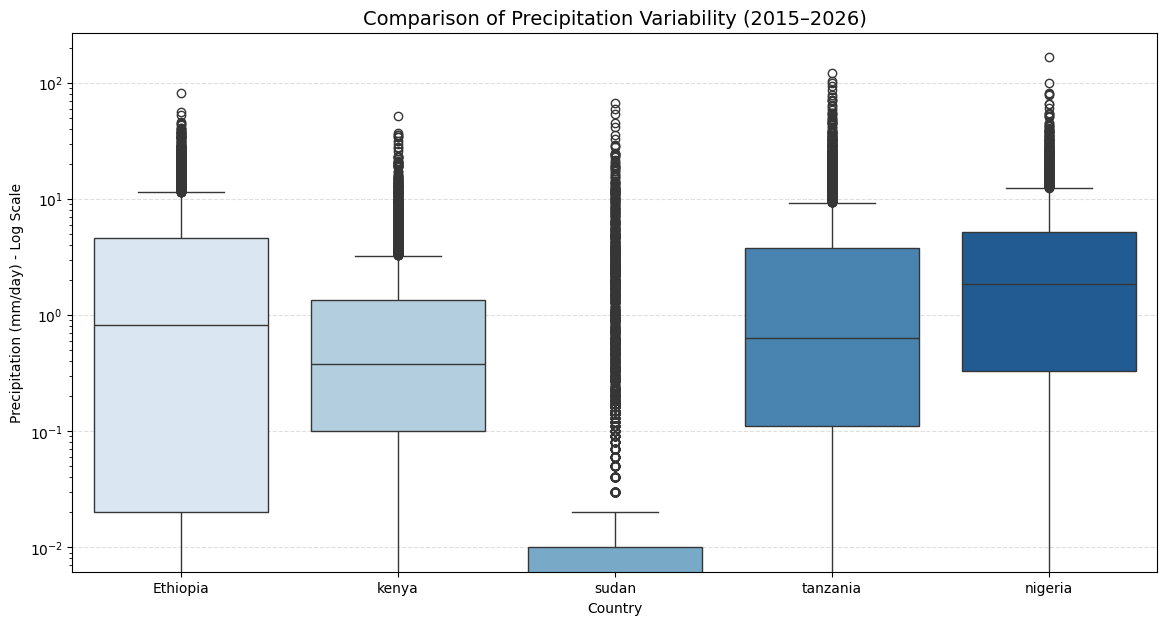

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))

# We use a log scale for the Y-axis because rain data often has 
# extreme outliers that compress the "box" part of the plot.
sns.boxplot(data=combined_df, x='Country', y='PRECTOTCORR', palette='Blues')

plt.yscale('log') # Log scale helps visualize the distribution better
plt.title("Comparison of Precipitation Variability (2015–2026)", fontsize=14)
plt.ylabel("Precipitation (mm/day) - Log Scale")
plt.xlabel("Country")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

In [7]:
# Generate summary statistics for Rainfall
precip_summary = combined_df.groupby('Country')['PRECTOTCORR'].agg(['mean', 'median', 'std']).reset_index()

# Formatting for the report
precip_summary.columns = ['Country', 'Mean Rain (mm)', 'Median Rain (mm)', 'Std Dev (Rain)']

# Display the table rounded to 2 decimal places
print("Comparison of Precipitation (PRECTOTCORR) Statistics")
display(precip_summary.round(2))

Comparison of Precipitation (PRECTOTCORR) Statistics


,Country,Mean Rain (mm),Median Rain (mm),Std Dev (Rain)
0,Ethiopia,3.63,0.82,6.29
1,kenya,1.47,0.38,3.18
2,nigeria,4.21,1.84,7.27
3,sudan,0.64,0.00,3.06
4,tanzania,3.74,0.64,8.00


Extreme Event Frequency

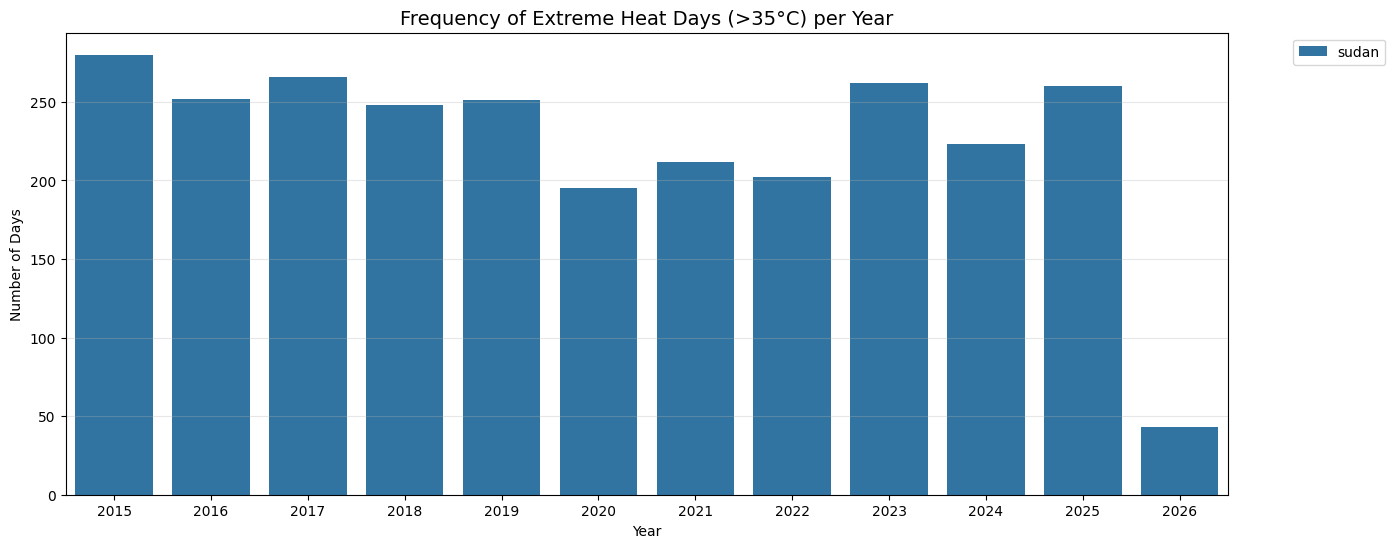

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ensure YEAR is extracted from our date column
combined_df['YEAR'] = combined_df['date'].dt.year

# 2. Count days > 35°C per year per country
heat_events = combined_df[combined_df['T2M_MAX'] > 35].groupby(['Country', 'YEAR']).size().reset_index(name='Days_Above_35')

# 3. Visualize
plt.figure(figsize=(15, 6))s
sns.barplot(data=heat_events, x='YEAR', y='Days_Above_35', hue='Country')

plt.title("Frequency of Extreme Heat Days (>35°C) per Year", fontsize=14)
plt.ylabel("Number of Days")
plt.xlabel("Year")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.show()

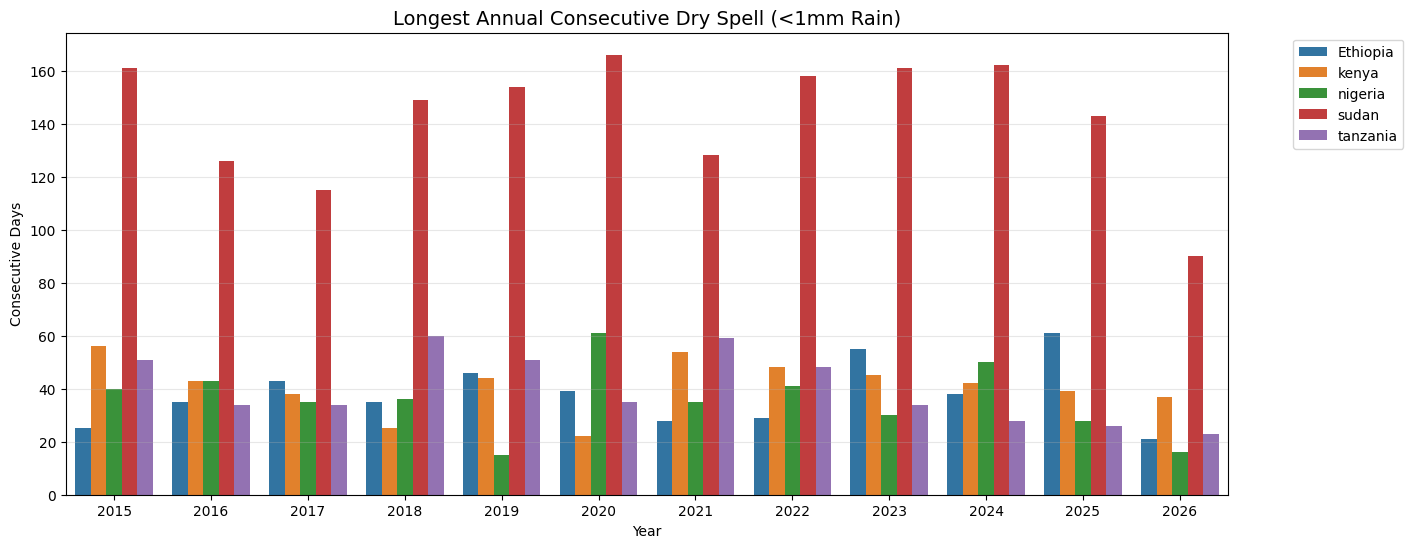

In [9]:
def get_max_dry_streak(series):
    # A day is 'dry' if rain < 1mm
    is_dry = series < 1
    # Group consecutive identical values
    streaks = is_dry.ne(is_dry.shift()).cumsum()
    # Filter for dry groups and count their size
    dry_streaks = is_dry.groupby(streaks).sum()
    return dry_streaks.max()

# Calculate the Max Dry Streak per Country per Year
dry_events = combined_df.groupby(['Country', 'YEAR'])['PRECTOTCORR'].apply(get_max_dry_streak).reset_index(name='Max_Dry_Streak')

# Visualize
plt.figure(figsize=(15, 6))
sns.barplot(data=dry_events, x='YEAR', y='Max_Dry_Streak', hue='Country')

plt.title("Longest Annual Consecutive Dry Spell (<1mm Rain)", fontsize=14)
plt.ylabel("Consecutive Days")
plt.xlabel("Year")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.show()

Vulnerability Ranking & Key Observations

### climate Vulnerability Ranking & Evidence Summary

| Rank | Country | Primary Risk Driver | Key Evidence (2015-2026) | Vulnerability |
| :--- | :--- | :--- | :--- | :--- |
| **1** | **Sudan** | Extreme Thermal Stress | >250 days/year over 35°C; Highest T2M volatility | **Critical** |
| **2** | **Nigeria** | Precipitation Instability | Highest density of rainfall outliers /flash flood risk| **High** |
| **3** | **Tanzania** | Humidity & Heat Shift | Consistent high thermal baseline with moderate variability | **Moderate** |
| **4** | **Kenya** | Seasonal Unpredictability | High variance in onset of rainy seasons | **Moderate** |
| **5** | **Ethiopia** | Highland Sensitivity | Lowest T2M but sensitive to rain shifts | **Baseline** |

-Rapid Warming is seen in Sudan.The data shows a consistent increase in T2M_MAX, with the frequency of extreme heat days (>35°C) frequently exceeding 250 days per year. This trend suggests an accelerating desertification process that threatens to make traditional outdoor labor and rain-fed agriculture untenable by the next decade.

-Precipitation Instability is seen in Nigeria.Nigeria exhibits the most unstable and extreme precipitation patterns. While it has a high mean rainfall,the boxplot analysis reveals the highest range of extreme outliers. This high variations in precipitation suggests that Nigeria could face flooding that destroys infrastructure.

-The high frequency of consecutive dry days and extreme heat reveals a region under intense climate stress.Prolonged drought streaks with a record high temperatures indicates a risk where water scarcity and heat stress occur simultaneously, leading to higher rates of crop failure and livestock mortality.

-Compared to its neighbors,Ethiopia maintains a significantly lower and more stable thermal profile. With an average T2M consistently 10–15°C cooler than Sudan,Ethiopia serves as a regional thermal refuge. However,its dependence on consistent rainfall for its highland water towers means it is highly sensitive to the shifting precipitation patterns seen in its neighbors.

-Ethiopia should champion Sudan for priority climate finance at COP32. The data provides an undeniable mandate since Sudan faces the most extreme thermal threshold crossings and the longest annual dry spells.Supporting Sudan is not only an act of regional solidarity but a strategic necessity for Ethiopia to prevent climate driven displacement and ensure the stability of shared transboundary resources.